## PART 1. 

## Section 1:  Introduction & model selection


This project seeks to model the behavior of airplane shock absorbers when landing under extreme conditions(at its maximum weight and allowed landing velocity), more concretely, the Airbus A380 oleo-pneumatic shock absorbers as our damped mechanical system- which functions by combining a pneumatic spring (compressed gas) with a hydraulic damper (oil flowing through an orifice) to manage energy absorption and dissipation. Our idea is to study how the strut, or the dampening system, responds after touchdown by modeling the initial compression and velocity before and after touchdown. 

The governing second-order ODE in use is given as follows: 

d²y/dt² + 2ζω dy/dt + ω²y = 0

We could interpret y as the displacement/compression of the strut, ω(omega) as its undamped natural frequency, ζ(zeta) as its damping ratio, d²y/dt² as the acceleration of the strut, and dy/dt as its velocity. To apply numerical methods we must convert the second order equation into first order, we must evaluate d²y/dt² as equal to -2ζω(dy/dt) - ω²y, where dy/dt = v. 

The final evaluation would be determined by whether the system would be underdamped, critically damped, or overdamped over a certain interval of time- using different step sizes,"h", to evaluate the accuracy and stability of the numerical methods.


## Section 2: Parameters and research justification

CONDITIONS BEING ASSUMED:

Weight( Max Weight Allowed of the Aircraft during Landing): 395, 000 kg
-According to the Airbus's A380 Aircraft Characteristics Manual, this is the maximum landing weight allowed. The weight can be distributed within 4 struts in the landing gear, and because about 90 percent of the aircraft weight is felt by these 4 struts when it lands, we can say that the mass = 0.9m(aircraft)/4 , which is around 88,875 kg. 

https://www.airbus.com/sites/g/files/jlcbta136/files/2021-11/Airbus-Aircraft-AC-A380.pdf 

Zeta: 0.7
-According to Katsuhiko Ogata, author of the book "Modern Control Engineering", a value of zeta between 0 and 1 means that the system is underdamped, meaning that our model will be described as oscillatory behavior with decreasing amplitude- this is realistic the realistic behavior of a landing strut after impact. 

https://mechfamily-ju.com/storage/images/files/file_17314308026pQTy.pdf

Static Compression:0.5 m
-Because exact strut design data is unavailable, we had to utilize the formula: k= mg/s to find the spring constant necessary to calculate ω(omega) using the other equation: √(k/m). For these formulas to work, we had to assume a static compression of the strut to be 0.5 meters as a reasonable constant since the strut is designed to support a significant stroke when landing. According to Virginia Tech, we can use these equations since we can use the static equilibrium of the oleo-neumatic strut to relate load and compression in a simplified spring model-which means that this is a common practice when analyzing this type of systems. 

https://archive.aoe.vt.edu/mason/Mason_f/M96SC05.pdf

Downward Velocity of the Landing Gear: -3.7 m/s

-According to the EASA (Easy Access Rules for Large Aeroplanes (CS-25)), this value was used in shock absorption tests to simulate real landing conditions- with a negative sign added to indicate downward motion. 

https://www.easa.europa.eu/en/document-library/easy-access-rules/online-publications/easy-access-rules-large-aeroplanes-cs-25?page=25#_DxCrossRefBm548991516

Gravity: 9.81 m/s^2

Time Interval: 0 to 5 seconds. 

-Used to capture the initial impact and the subsequent damping behavior of the strut.

Step Size interval(h): 0.5, 0.1, 0.05, 0.01. 

-In order to test the accuracy for each numerical method, since both are sensible to the step size range, we decided to select four carefully step sizes from a "large" value of 0.5 to a small value of "0.01." 


## Section 3: Numerical methods implementation

The numerical explicit methods we decided to utilize are Euler's Forward and 4th order Runge-Kutta(RK4) methods.

Our implementation approach for Euler's Forward method was to convert the second-order ODE to two first-order ODEs, where the code works iteratively by taking discrete steps along the tangent line of the equation and using the derivative at the current point to calculate the next point. The function named "Euler_method" initializes the function using the initial conditions stablished, create "empty" arrays x_values,y_values, and v_values and then store, in order, the updated solution that y_values[i] and its derivative, v_values[i], provide. 

RK4 works by finding an improved method to approximate the solution up to a specific order of error. To do that, we had to define the displacement and the velocity by using the functions "displacement" and "displacement_rhs." 

Then, we created our RK4 function, which takes initial parameters, the displacements, and empty arrays t_values,y_values, and v_values, to find and store the solution using:

1)k1_d/v as the slope at the beginning of the interval
2)k2_d/v the slope at the midpoint of the step using k1_d/v
3)k3_d/v as another slope at the midpoint, but estimated using to improve accuracy k2_d/v
4)k4_d/v as the slope at the end of the step, estimated using k3_d/v. 

In the end, to achieve a fourth-order method, we had to combine all of those slopes by using y_values[i] and v_values[i] in using the coefficients 1/6,1/3,1/3,1/6 to ensure that the error in the method is O(h 5) per step. 



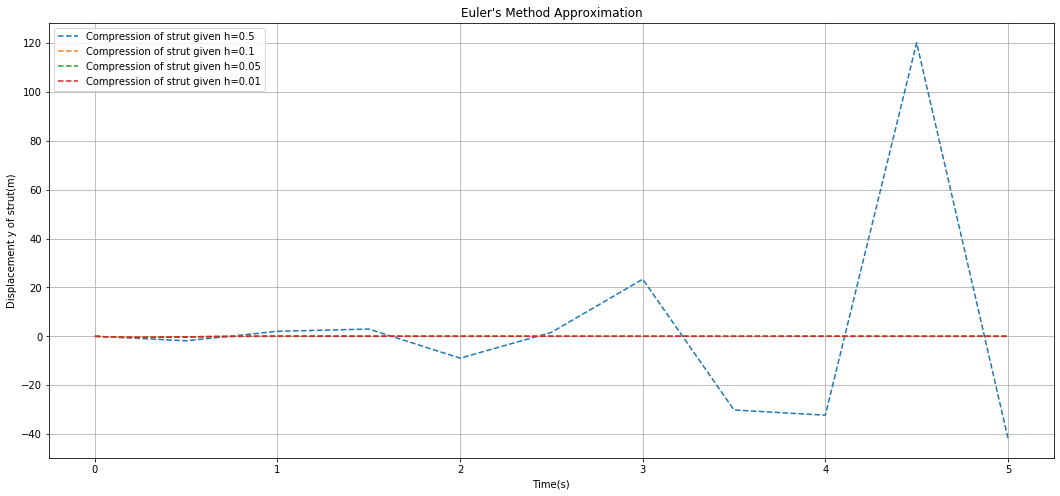

     Time (s)|  Displacement y (m)|  Velocity v (m/s)|
0          0.0         0.000000e+00      -3.700000e+00
100        1.0         6.421046e-03       1.461290e-01
200        2.0        -5.762912e-04      -5.552637e-03
300        3.0         3.859826e-05       1.996756e-04
400        4.0        -2.286316e-06      -6.571823e-06
500        5.0         1.263061e-07       1.817032e-07


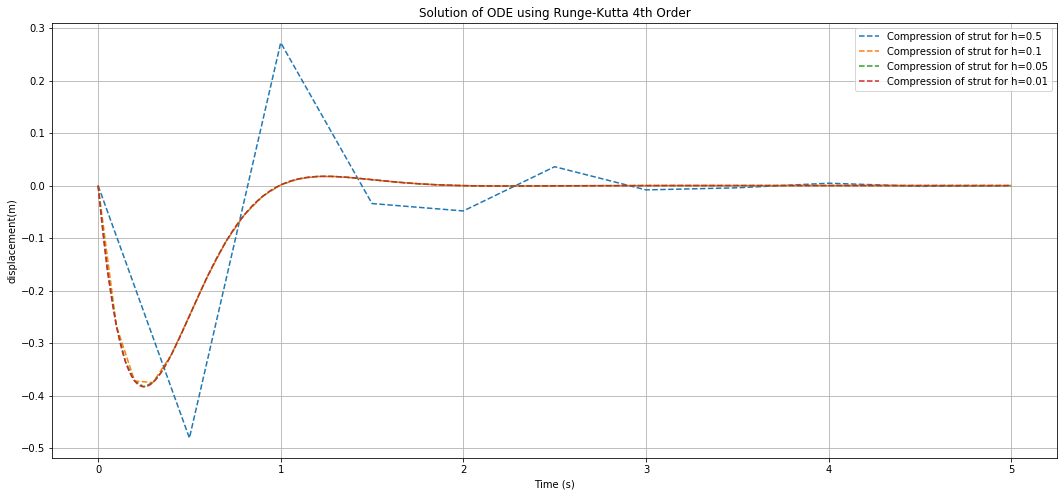

     Time (s)|  Displacement y (m)|  Velocity v (m/s)|
0          0.0         0.000000e+00      -3.700000e+00
100        1.0         1.140823e-03       1.630036e-01
200        2.0        -1.026992e-04      -7.174224e-03
300        3.0         6.932812e-06       3.154393e-04
400        4.0        -4.159405e-07      -1.385475e-05
500        5.0         2.339139e-08       6.078549e-07


In [137]:
#Solving a Second ODE using Euler's method, first part 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Defining the parameters

z = 0.7 # Constant in the equation, zeta, as the damping ratio
g = 9.81 #Gravity, in m/s^2
m = 88875 #Mass, in kilograms 
s = 0.5 #Assumed static compression to find k

h_val = [0.5, 0.1, 0.05, 0.01] # Step size, time interval in 10 miliseconds 
t_start = 0 # Start of the interval
t_end = 5 # End of the interval
y_0 = 0 # Initial condition for y, which assumes the compression in the strut before landing is 0 cm
v_0 = -3.7 # Initial condition for dy/dx, the downward velocity, in m/s, of the plane 


#Equations to find variables:
k = m*g / s 
w = np.sqrt(k/m)
plt.figure(figsize=(18, 8))
# Create arrays to store x, y, and v values
def euler_method(y0, v0, t_start, t_end, h):
        x_values = np.arange(t_start, t_end + h, h)
        y_values = np.zeros(len(x_values))
        v_values = np.zeros(len(x_values))
# St initial conditions
        y_values[0] = y_0
        v_values[0] = v_0

# Euler's Method loop
        for i in range(1, len(x_values)):
    # Current values
            y_n = y_values[i - 1]
            v_n = v_values[i - 1]
# Update equations
            y_values[i] = y_n + h * v_n
            v_values[i] = v_n + h * (-2*z*w*v_n - w**2 * y_n)
        return x_values, y_values, v_values

# Plot the results

for h in h_val:
    x_values, y_values, v_values = euler_method(y_0, v_0, t_start, t_end, h)
    plt.plot(x_values, y_values, linestyle='--', label=f"Compression of strut given h={h}")
    
plt.xlabel('Time(s)')
plt.ylabel('Displacement y of strut(m)')
plt.title('Euler\'s Method Approximation')
plt.grid(True)
plt.legend()
plt.show()

#We used ChatGPT to help us construct a nice chart containing the simulated data obtained

table = pd.DataFrame({
    "Time (s)|": ,
    "Displacement y (m)|": ,
    "Velocity v (m/s)|": 
})
table_sample = table.iloc[::100]   # a set of values at every 100th point
print(table_sample)

#-------------------------------------------------------------------------------------------------------------------------

# Defining the ODE function
def displacement(y, v):
    return v

def displacement_rhs(y, v):
    return -2*z*w*v - w**2 * y
plt.figure(figsize=(18, 8))
# Implement the RK4 method
def runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h):
# Create an array for time steps
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(y_values))
# Set the initial condition
    y_values[0] = y_0
    v_values[0] = v_0
# Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]
        k1_d = h * displacement(y, v)
        k1_v = h * displacement_rhs(y, v)
        
        k2_d = h * displacement(y + k1_d / 2, v + k1_v / 2)
        k2_v = h * displacement_rhs(y + k1_d/ 2, v + k1_v / 2)
        
        k3_d = h * displacement(y + k2_d / 2, v + k2_v / 2)
        k3_v = h * displacement_rhs(y + k2_d/ 2, v + k2_v / 2)
        
        k4_d = h * displacement(y + k3_d, v + k3_v)
        k4_v = h * displacement_rhs(y + k3_d, v + k3_v)
        
        # Update y based on the RK4 formula
        y_values[i] = y + (k1_d + 2 * k2_d + 2 * k3_d + k4_d) / 6
        v_values[i] = v + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
    return v_values, y_values, t_values


# Run the RK4 solver
for h in h_val:
    v_values, y_values, t_values = runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h)
    plt.plot(t_values, y_values, linestyle='--', label=f'Compression of strut for h={h}')
# Plot the results
 
plt.xlabel('Time (s)')
plt.ylabel('displacement(m)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

table = pd.DataFrame({
    "Time (s)|": t_values,
    "Displacement y (m)|": y_values,
    "Velocity v (m/s)|": v_values
})
table_sample = table.iloc[::100]   # a set of values at every 100th point
print(table_sample)


## Section 4: Solutions & Comparison



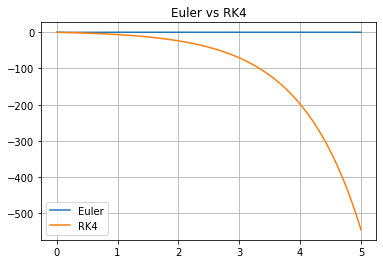

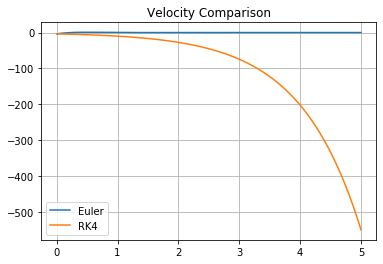

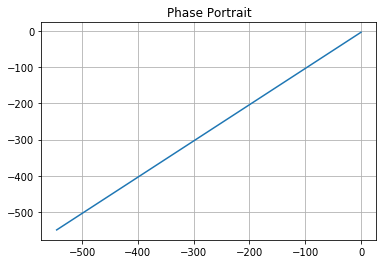

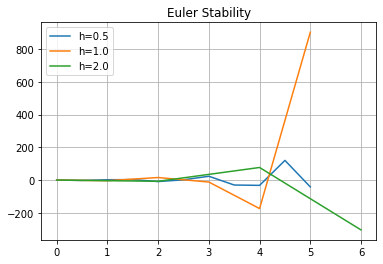

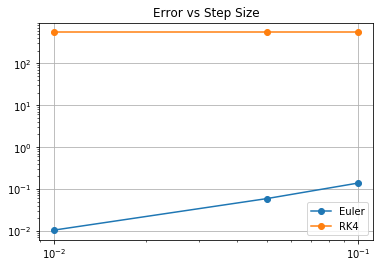

In [135]:
#Comparing graphs:

plt.figure()
h = 0.01
t_e, y_e, v_e = euler_method(y_0, v_0, t_start, t_end, h)
v_rk, y_rk, t_rk = runge_kutta_4(velocity, y_0, v_0, t_start, t_end, h)

plt.plot(t_e, y_e, label='Euler')
plt.plot(t_rk, y_rk, label='RK4')

plt.legend()
plt.grid()
plt.title("Euler vs RK4")
plt.show()


# Velocity
plt.figure()
plt.plot(t_e, v_e, label='Euler')
plt.plot(t_rk, v_rk, label='RK4')
plt.legend()
plt.title("Velocity Comparison")
plt.grid()
plt.show()

# velocity vs displacement for system stability
plt.figure()
plt.plot(y_rk, v_rk)
plt.title("Phase Portrait")
plt.grid()
plt.show()


# Stability test for Euler method using large step sizes to check divergence
plt.figure()

for h in [0.5, 1.0, 2.0]:
    t_s, y_s, _ = euler_method(y_0, v_0, t_start, t_end, h)
    plt.plot(t_s, y_s, label=f"h={h}")

plt.title("Euler Stability")
plt.legend()
plt.grid()
plt.show()


# Compute numerical error for Euler and RK4 methods
def analytical_solution(t):
    wd = w * np.sqrt(1 - z**2)
    C1 = y_0
    C2 = (v_0 + z*w*y_0) / wd
    return np.exp(-z*w*t) * (C1*np.cos(wd*t) + C2*np.sin(wd*t))


h_values_error = [0.1, 0.05, 0.01]
euler_errors = []
rk4_errors = []

for h in h_values_error:
    t_vals, y_e, _ = euler_method(y_0, v_0, t_start, t_end, h)
    v_rk, y_rk, t_rk = runge_kutta_4(velocity, y_0, v_0, t_start, t_end, h)

    y_true = analytical_solution(t_vals)

    euler_errors.append(np.max(np.abs(y_true - y_e)))
    rk4_errors.append(np.max(np.abs(y_true - y_rk)))


plt.figure()
plt.loglog(h_values_error, euler_errors, 'o-', label='Euler')
plt.loglog(h_values_error, rk4_errors, 'o-', label='RK4')
plt.legend()
plt.title("Error vs Step Size")
plt.grid()
plt.show()

## Section 5: Stability Analysis 

a) Solution accuracy differs from both of the implemented numerical methods. For Euler's Forward, the smaller the step size the more unstable the graphed solution becomes- as it starts exhibiting large fluctuations whith values lower than h = 0.01, making it the maximum stable step size. Contrary to Euler, for RK4 the larger the step size the more unstable the graph becomes- whose maximum stable step size value is h = 0.1. 

b)

## Section 6: Conclusions



"""COE_Final_Project_part1.pynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1APDS9s6kDyhssiEgvqo1HRvoOEJuCbCf

## PART 1.

## Section 1:  Introduction & model selection


This project seeks to model the behavior of airplane shock absorbers when landing under extreme conditions (at its maximum weight and allowed landing velocity), more concretely, the Airbus A380 oleo-pneumatic shock absorbers as our damped mechanical system- which functions by combining a pneumatic spring (compressed gas) with a hydraulic damper (oil flowing through an orifice) to manage energy absorption and dissipation. Our idea is to study how the strut, or the dampening system, responds after touchdown by modeling the initial compression and velocity before and after touchdown. The reason we chose this system is because it maps cleanly onto a classical damped oscillator, and the physical parameters are well-documented enough to justify realistic values.

The governing second-order ODE in use is given as follows:

d²y/dt² + 2ζω dy/dt + ω²y = 0

We could interpret y as the displacement/compression of the strut, ω(omega) as its undamped natural frequency, ζ(zeta) as its damping ratio, d²y/dt² as the acceleration of the strut, and dy/dt as its velocity. To apply numerical methods we must convert the second order equation into first order, we must evaluate d²y/dt² as equal to -2ζω(dy/dt) - ω²y, where dy/dt = v. This gives us a system of two coupled first-order ODEs that we can step through numerically:

    y₁' = y₂
    y₂' = -2ζω·y₂ - ω²·y₁

where y₁ is the strut compression and y₂ is its rate of change.

The final evaluation would be determined by whether the system would be underdamped, critically damped, or overdamped over a certain interval of time- using different step sizes, "h", to evaluate the accuracy and stability of the numerical methods. Because ζ = 0.7 falls between 0 and 1, we expect underdamped behavior: a few decaying oscillations before the strut settles at equilibrium.

## Section 2: Parameters and research justification

CONDITIONS BEING ASSUMED:

Weight (Max Weight Allowed of the Aircraft during Landing): 395,000 kg
-According to the Airbus A380 Aircraft Characteristics Manual, this is the maximum landing weight allowed. The weight can be distributed within 4 struts in the landing gear, and because about 90 percent of the aircraft weight is felt by these 4 struts when it lands, we can say that the mass = 0.9m(aircraft)/4, which is around 88,875 kg.

https://www.airbus.com/sites/g/files/jlcbta136/files/2021-11/Airbus-Aircraft-AC-A380.pdf

Zeta: 0.7
-According to Katsuhiko Ogata, author of the book "Modern Control Engineering", a value of zeta between 0 and 1 means that the system is underdamped, meaning that our model will be described as oscillatory behavior with decreasing amplitude- this is the realistic behavior of a landing strut after impact. A value of 0.7 is also commonly used in aerospace applications as a design target because it balances fast settling time with minimal overshoot.

https://mechfamily-ju.com/storage/images/files/file_17314308026pQTy.pdf

Static Compression: 0.5 m
-Because exact strut design data is unavailable, we had to utilize the formula: k = mg/s to find the spring constant necessary to calculate ω(omega) using the other equation: √(k/m). For these formulas to work, we had to assume a static compression of the strut to be 0.5 meters as a reasonable constant since the strut is designed to support a significant stroke when landing. According to Virginia Tech, we can use these equations since we can use the static equilibrium of the oleo-pneumatic strut to relate load and compression in a simplified spring model- which means that this is a common practice when analyzing this type of system. From these two values we get k ≈ 1,746,699 N/m and ω ≈ 4.43 rad/s.

https://archive.aoe.vt.edu/mason/Mason_f/M96SC05.pdf

Downward Velocity of the Landing Gear: -3.7 m/s
-According to the EASA (Easy Access Rules for Large Aeroplanes (CS-25)), this value was used in shock absorption tests to simulate real landing conditions- with a negative sign added to indicate downward motion. This is the worst-case sink rate the strut is certified to handle, so it represents a good upper bound for our simulation.

https://www.easa.europa.eu/en/document-library/easy-access-rules/online-publications/easy-access-rules-large-aeroplanes-cs-25?page=25#_DxCrossRefBm548991516

Gravity: 9.81 m/s^2

Time Interval: 0 to 5 seconds.
-Used to capture the initial impact and the subsequent damping behavior of the strut. Given our damping ratio and natural frequency, the system should settle well within this window, which makes 5 seconds a physically meaningful endpoint.

Step Size interval (h): 0.5, 0.1, 0.05, 0.01.
-In order to test the accuracy for each numerical method, since both are sensitive to the step size range, we decided to select four carefully chosen step sizes from a "large" value of 0.5 to a "small" value of 0.01. This range lets us observe both stable and unstable behavior and see how the error scales as h decreases.

## Section 3: Numerical methods implementation

The numerical explicit methods we decided to utilize are Euler's Forward and 4th order Runge-Kutta (RK4) methods.

Our implementation approach for Euler's Forward method was to convert the second-order ODE to two first-order ODEs, where the code works iteratively by taking discrete steps along the tangent line of the equation and using the derivative at the current point to calculate the next point. The function named "euler_method" initializes the function using the initial conditions established, creates "empty" arrays x_values, y_values, and v_values and then stores, in order, the updated solution that y_values[i] and its derivative, v_values[i], provide. Because Euler only uses the slope at the beginning of each step, its local error is O(h²) per step and O(h) globally- meaning accuracy degrades quickly if h is too large.

RK4 works by finding an improved method to approximate the solution up to a specific order of error. To do that, we had to define the displacement and the velocity by using the functions "displacement" and "displacement_rhs."

Then, we created our RK4 function, which takes initial parameters, the displacements, and empty arrays t_values, y_values, and v_values, to find and store the solution using:

1) k1_d/v as the slope at the beginning of the interval
2) k2_d/v the slope at the midpoint of the step using k1_d/v
3) k3_d/v as another slope at the midpoint, but estimated using k2_d/v to improve accuracy
4) k4_d/v as the slope at the end of the step, estimated using k3_d/v.

In the end, to achieve a fourth-order method, we had to combine all of those slopes by using y_values[i] and v_values[i] using the coefficients 1/6, 1/3, 1/3, 1/6 to ensure that the error in the method is O(h^5) per step and O(h^4) globally. This means that cutting h in half reduces RK4's error by a factor of roughly 16, compared to just 2 for Euler- a significant advantage for problems that need high accuracy without an extremely small step size.

Because this system has a known analytical solution (since ζ < 1), we can compute the exact answer at every time step and use it as a benchmark to measure how far each numerical method drifts. The closed-form solution for the underdamped case is:

    y(t) = e^(-ζωt) * [C1·cos(ωd·t) + C2·sin(ωd·t)]

where ωd = ω√(1-ζ²) is the damped natural frequency, and C1, C2 are set by the initial conditions. Having this reference is what allows us to produce meaningful error plots rather than just comparing the two numerical methods to each other.
"""